In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data of gurugram real Estate.csv")

In [3]:
#Data Cleaning
df.isnull()
df.dropna()
df = df.drop_duplicates()
df.columns = df.columns.str.strip().str.lower().str.replace(' ' , '_')
print(df.columns)

Index(['price', 'status', 'area', 'rate_per_sqft', 'property_type', 'locality',
       'builder_name', 'rera_approval', 'bhk_count', 'society', 'company_name',
       'flat_type'],
      dtype='object')


In [4]:
#Numeric columns cleaning
df['price'] = df['price'].astype(str).str.replace(",","").astype(float)
print(df['price'])

df['area'] = df['area'].astype(str).str.replace(",","").astype(int)
print(df['area'])

df['rate_per_sqft'] = df['rate_per_sqft'].astype(str).str.replace(",","").astype(int)
print(df['rate_per_sqft'])

0        10700000.0
1        14400000.0
2        10700000.0
3        40000000.0
4        24000000.0
            ...    
19510    24100000.0
19511    36200000.0
19512    39100000.0
19513    37700000.0
19514    36500000.0
Name: price, Length: 14223, dtype: float64
0        1138
1        1528
2        1138
3        4500
4        1800
         ... 
19510    1381
19511    2072
19512    2445
19513    2360
19514    2282
Name: area, Length: 14223, dtype: int64
0         9450
1         9450
2         9450
3         8888
4        13333
         ...  
19510    17500
19511    17500
19512    16002
19513    16001
19514    16005
Name: rate_per_sqft, Length: 14223, dtype: int64


In [5]:
#cartegorial column Cleaning
df['status'] = df['status'].str.strip().str.lower()
df['rera_approval'] = df['rera_approval'].str.strip().map({'Approved by RERA':True,'Not approved by RERA':False})
df['flat_type'] = df['flat_type'].str.strip().str.lower()

In [6]:
df = df.drop_duplicates()
print(f"{df.info()}")

<class 'pandas.core.frame.DataFrame'>
Index: 14223 entries, 0 to 19514
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          14223 non-null  float64
 1   status         14223 non-null  object 
 2   area           14223 non-null  int64  
 3   rate_per_sqft  14223 non-null  int64  
 4   property_type  14223 non-null  object 
 5   locality       14223 non-null  object 
 6   builder_name   14223 non-null  object 
 7   rera_approval  14223 non-null  bool   
 8   bhk_count      14223 non-null  int64  
 9   society        14223 non-null  object 
 10  company_name   14223 non-null  object 
 11  flat_type      14223 non-null  object 
dtypes: bool(1), float64(1), int64(3), object(7)
memory usage: 1.3+ MB
None


In [7]:
##Ques 1.) Which is the costliest flat in the dataset?
costliest_flat = df.loc[df['price'].idxmax()]
print(costliest_flat)

price                                1226300000.0
status                              ready to move
area                                        16500
rate_per_sqft                               74323
property_type    6 BHK Apartment in DLF Camellias
locality                                Sector 42
builder_name                    Provident Capital
rera_approval                               False
bhk_count                                       6
society                             DLF Camellias
company_name                                  DLF
flat_type                               apartment
Name: 2839, dtype: object


In [8]:
# converting data into sentences
print(f"The Costliest flat is {costliest_flat['bhk_count']}BHK flat loacte in {costliest_flat['locality']} priced at {costliest_flat['price']}.")

The Costliest flat is 6BHK flat loacte in Sector 42 priced at 1226300000.0.


In [9]:
##Ques 2.) Which locality has the highest average price?
highAvg_Loccality = df.groupby('locality')['price'].mean().idxmax()
print(f"Highest average price locality is {highAvg_Loccality}.")

Highest average price locality is Baliawas.


In [10]:
print(f"10 Highest average price locality is {df.groupby('locality')['price'].mean().sort_values(ascending=False).head(10)}.")

10 Highest average price locality is locality
Baliawas                  5.833333e+08
Sector 42                 5.023612e+08
Beverly Park              1.953667e+08
Aralias Drive             1.636583e+08
Golf Course Road          1.475139e+08
Sector 73                 1.281941e+08
37D Dwarka Exp Gurgaon    1.197000e+08
Ambience Island           1.100000e+08
Sector 24                 1.086423e+08
Sector 113                9.808106e+07
Name: price, dtype: float64.


In [11]:
##Ques 3.) Which locality has the highest rate per square foot?
Highest_rateSqFoot_Locality = df.groupby('locality')['rate_per_sqft'].mean().idxmax()
print(f"Locality with highest Rate per Square foot is {Highest_rateSqFoot_Locality}.")

Locality with highest Rate per Square foot is Sector 42.


In [12]:
##Ques 4.)Do ready-to-move properties cost more than under-construction properties?
Ready_to_move_AvgPrice = df[df['status']=='ready to move']['price'].mean()
UnderConstruction_AvgPrice = df[df['status']=='under construction']['price'].mean()

if Ready_to_move_AvgPrice > UnderConstruction_AvgPrice:
    print("Ready to move costs more on average than Under-construction properties.")
else:
    print("Under-construction costs more on average than Ready to move  properties.")

Ready to move costs more on average than Under-construction properties.


In [13]:
##Ques 5.) Do RERA-approved properties command a price premium?
RERA_approved_AvgPrice = df[df['rera_approval']==True]['price'].mean()
RERA_Notapproved_AvgPrice = df[df['rera_approval']==False]['price'].mean()

if RERA_approved_AvgPrice > RERA_Notapproved_AvgPrice :
    print("RERA-approved properties command a price premium.")
else :
    print("RERA-approved properties do not command a price premium.")

RERA-approved properties do not command a price premium.


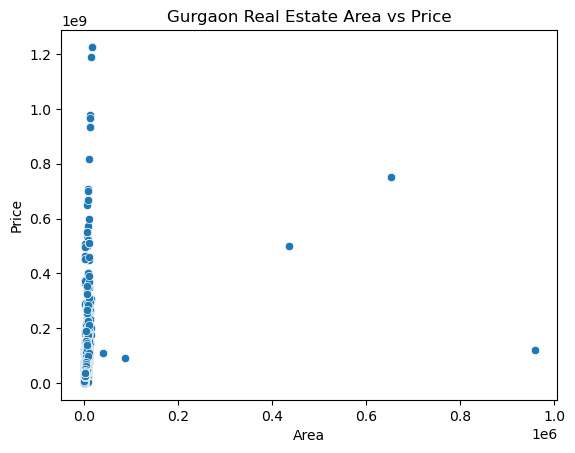

<Figure size 640x480 with 0 Axes>

In [21]:
##Ques 6.) How does area (sqft) impact property price?
sns.scatterplot(x="area", y="price", data=df) #visual evidence
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Gurgaon Real Estate Area vs Price")
plt.show()
plt.savefig("area_vs_price.png")

In [15]:
#Numerical evidence ranges -1 to +1 
corr = df['area'].corr(df['price'])
if corr > 0:
    print("Area and price have a positive relationship.")
else:
    print("Area and price have a Negative relationship.")

Area and price have a positive relationship.


In [16]:
##Ques 7.) Which BHK configuration is the most expensive on average based on Price?
Highest_AvgBHK = df.groupby('bhk_count')['price'].mean().idxmax()
print(f"Most expensive BHK on an average is {Highest_AvgBHK}BHK")

Most expensive BHK on an average is 7BHK


In [17]:
##Ques 8.) Which property type (Apartment, Floor, Plot) is the costliest?
Costliest_propertyType = df.groupby('flat_type')['price'].mean().idxmax()
print(f"Costliest property Type is {Costliest_propertyType}")

Costliest property Type is penthouse


In [18]:
##Ques 9.) Do certain builders or companies consistently price higher based on rate per sq foot?
Costly_companies_AvgPrices = df.groupby('company_name')['rate_per_sqft'].mean().sort_values(ascending=False).head(10)
print(Costly_companies_AvgPrices)

print(f"\nTop 10 Costly comapnies are :")
for company in Costly_companies_AvgPrices.index :
  print(company)

company_name
Camelliaass    44724.333333
Cameliaas      40000.000000
Tulip          28571.121495
Prom           27358.600000
Magnoliaass    26666.000000
Magnoliaaa     25000.000000
M3M            24319.304065
Tribeca        24119.320000
B              24019.172414
DLF            23541.756338
Name: rate_per_sqft, dtype: float64

Top 10 Costly comapnies are :
Camelliaass
Cameliaas
Tulip
Prom
Magnoliaass
Magnoliaaa
M3M
Tribeca
B
DLF


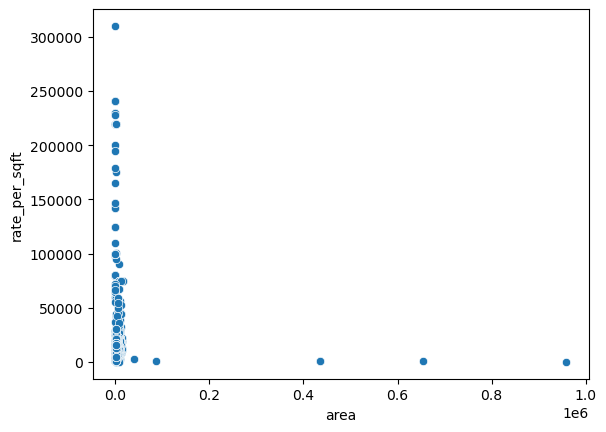

<Figure size 640x480 with 0 Axes>

In [22]:
##Ques 10.) Are larger homes always more expensive per square foot?
sns.scatterplot(x="area", y="rate_per_sqft",data=df)  #visual evidance
plt.show()

plt.savefig("area_vs_ratepersqft.png")

In [20]:
corr = df['area'].corr(df['rate_per_sqft']) #Numeric evidence

if corr > 0:
    print("Larger homes tend to have a higher rate per sqft.")
else:
    print("Larger homes are not necessarily more expensive per sqft.")

Larger homes are not necessarily more expensive per sqft.
